In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dfs = {}
years = ['2021', '2022', '2023', '2024', '2025']

for year in years:
    dfs[year] = pd.read_csv(f'financial_data_{year}.csv')

/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1164/448918627.py:5: DtypeWarning: Columns (0: expl2510) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1164/448918627.py:5: DtypeWarning: Columns (0: expl2300, 1: expl2900, 2: expl2100, 3: expl2500, 4: expl2310, 5: expl2510) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1164/448918627.py:5: DtypeWarning: Columns (0: expl2400, 1: expl2900, 2: expl2100, 3: expl2500) have mixed types. Specify dtype option on import or set low_memory=False.
  dfs[year] = pd.read_csv(f'financial_data_{year}.csv')
/var/folders/9r/612l79zx42z643jnmxxshb1m0000gn/T/ipykernel_1164/448918627.py:5: DtypeWarning: Columns (0: expl2300, 1: expl2900, 2: expl2500, 3: expl2310) hav

**Готовим x**

In [3]:
xy=pd.DataFrame()
for N in range(1,5):
    year = '2025'
    prev_year = str(2025 - N)
    x_name = f'{N}x'

    curr = pd.to_numeric(dfs[year]['current2400'], errors='coerce')
    prev = pd.to_numeric(dfs[prev_year]['current2400'], errors='coerce')
    
    prev_safe = prev.replace(0, np.nan)
    
    xyN = ((curr - prev_safe) / prev_safe * 100).round(-1)
    
    xy[x_name] = xyN.astype('Int64')

**Готовим y**

In [4]:
for N in range(1,5):
    x_name = f'{N}x'
    y_name = f'{N}y'

    counts = xy[x_name].value_counts()

    xy[y_name] = xy[x_name].map(counts)
xy

,1x,2x,3x,4x,1y,2y,3y,4y
0,-100,-100,-100,-120,1604,1540,1440,142
1,10,780,70,0,65,6,58,71
2,2330,20,2140,3360,1,58,2,1
3,920,-140,-30,-120,6,89,85,142
4,10,200,1690,2790,65,25,1,2
...,...,...,...,...,...,...,...,...
9217,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9218,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9219,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
9220,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


**Строим график**

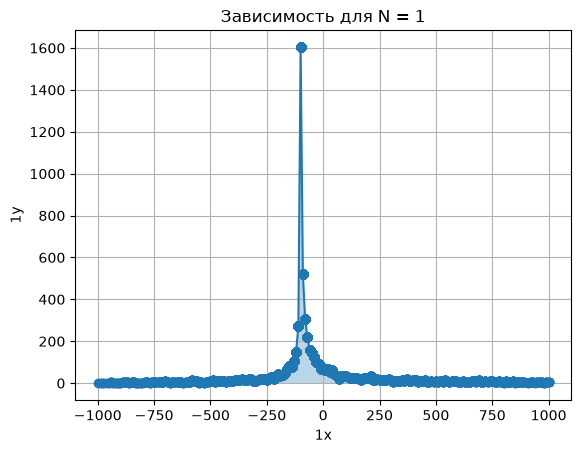

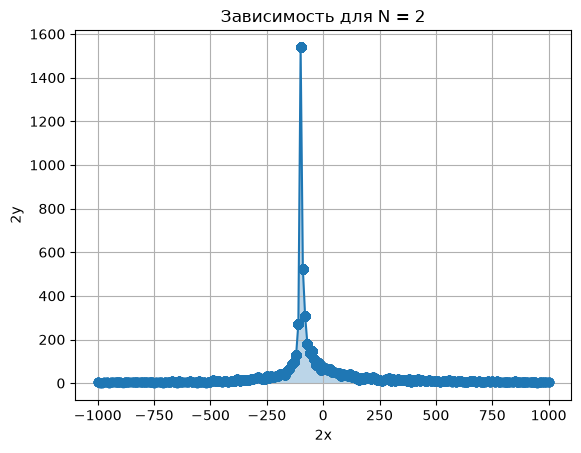

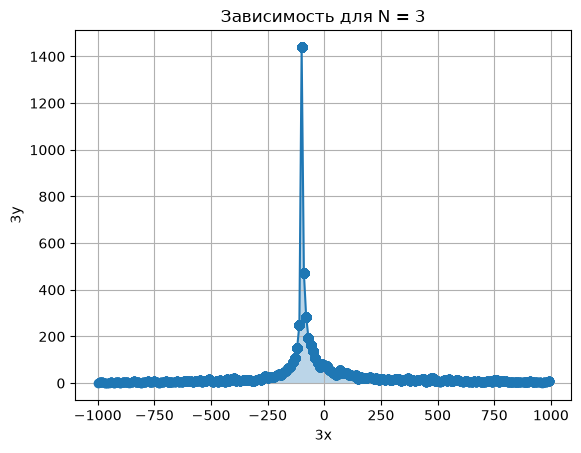

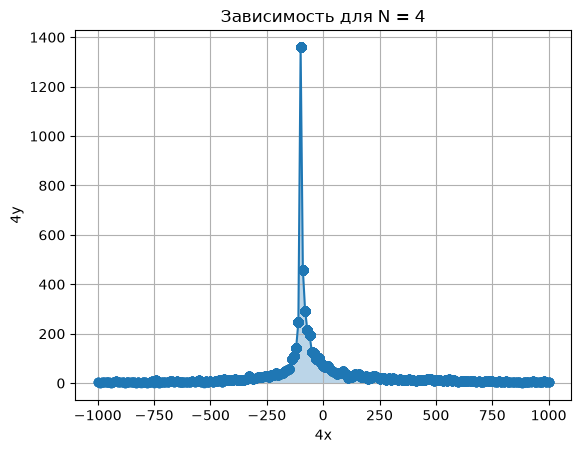

In [9]:
for N in range(1,5):
    x_name = f'{N}x'
    y_name = f'{N}y'

    mask = xy[x_name].abs() <= 1000
    x_f = xy.loc[mask, x_name]
    y_f = xy.loc[mask,y_name]

    sorted_idx = x_f.argsort()
    x_sorted = x_f.iloc[sorted_idx]
    y_sorted = y_f.iloc[sorted_idx]

    plt.figure()
    plt.plot(x_sorted, y_sorted, 'o-')
    plt.fill_between(x_sorted, y_sorted, alpha = 0.3)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title(f'Зависимость для N = {N}')
    plt.grid(True)
    plt.show()

**Выводы по графикам**

**1. Отрасль сжимается** \
Т.к. вершины всех графиков сдвинуты влево от нуля, т.е. болльшинство компаний показали отрицательный рост чистой прибыли\
\
**2. Низкая волатильность**\
Колокольчик узкий, дисперсия маленькая, отрасль стабильная, без инноваций и прочего\
\
**3. Наблюдается относительно стабильное сжатие отрасли**\
Вершина колокольчика относительно неподвижна\
\
**4. Сравнение с EBITA**\
Принимая во внимание аналогичную ситуациюю с ебита, можно сделать вывод, что все действительно не здорово

